# Proyecto IA 1 - Parcial 2
**Integrantes:** Santiago Ardila, Santiago Flórez, María Lucía Rodríguez

**Códigos:** 2230086, 2230096, 2231853
![ckd](https://drive.google.com/uc?export=view&id=15_Cijtvt6Jp3O3XjtnJN4MTBmDU3Ijps)

# Subida de datos

In [ ]:
# Importar librerias y cargar el drive para agregar el dataset
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import *

path_ai = "/IA/Proyecto"
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1sCHJYLzYRzxjAg4ej7k-oy-pY65IHBhM/Proyecto


In [ ]:
# Cargar el dataset
dataset = pd.read_csv("/content/drive/MyDrive/IA/Proyecto/ckd_stages_dataset.csv")

In [ ]:
# Renombrar las variables para que sean más legible
col={'age': 'age',
     'bp': 'blood_pressure',
     'sg': 'specific_gravity',
     'al': 'albumin',
     'su': 'sugar',
     'rbc': 'red_blood_cells',
     'pc': 'pus_cell',
     'pcc': 'pus_cell_clumps',
     'ba': 'bacteria',
     'bgr': 'blood_glucose_random',
     'bu': 'blood_urea',
     'sc': 'serum_creatinine',
     'sod': 'sodium',
     'pot': 'potassium',
     'hemo': 'hemoglobin',
     'pcv': 'packed_cell_volume',
     'wc': 'white_blood_cell_count',
     'rc': 'red_blood_cell_count',
     'htn': 'hypertension',
     'dm': 'diabetes_mellitus',
     'cad': 'coronary_artery_disease',
     'appet': 'appetite',
     'pe': 'pedal_edema',
     'ane': 'anemia',
     'classification': 'class'}
dataset.rename(columns=col, inplace=True)

In [ ]:
# Convertir columnas númericas mal tipadas (guardadas como strings)
dataset['packed_cell_volume'] = pd.to_numeric(dataset['packed_cell_volume'].str.strip().replace('?', None), errors='coerce')
dataset['white_blood_cell_count'] = pd.to_numeric(dataset['white_blood_cell_count'].str.strip().replace('?', None), errors='coerce')
dataset['red_blood_cell_count'] = pd.to_numeric(dataset['red_blood_cell_count'].str.strip().replace('?', None), errors='coerce')

# Limpiar espacios y tabulaciones en variables categóricas y en class
dataset['diabetes_mellitus'] = dataset['diabetes_mellitus'].str.strip()
dataset['coronary_artery_disease'] = dataset['coronary_artery_disease'].str.strip()
dataset['class'] = dataset['class'].str.strip()

# Corregir la concordancia de los datos
dataset.loc[dataset['class'] == 'notckd', 'ckd_stage'] = 0
dataset.loc[dataset['ckd_stage'] == 0, 'class'] = 'notckd'

# Imputación de datos

In [ ]:
# Mapeamos los valores de las variables categóricas para facilitar los modelos
dataset['hypertension'] = dataset['hypertension'].map({'yes': 1, 'no': 0})
dataset['pedal_edema'] = dataset['pedal_edema'].map({'yes': 1, 'no': 0})
dataset['diabetes_mellitus'] = dataset['diabetes_mellitus'].map({'yes': 1, 'no': 0})
dataset['red_blood_cells'] = dataset['red_blood_cells'].map({'abnormal': 1, 'normal': 0})
dataset['anemia'] = dataset['anemia'].map({'yes': 1, 'no': 0})
dataset['appetite'] = dataset['appetite'].map({'poor': 1, 'good': 0})
dataset['pus_cell'] = dataset['pus_cell'].map({'abnormal': 1, 'normal': 0})
dataset['pus_cell_clumps'] = dataset['pus_cell_clumps'].map({'present': 1, 'notpresent': 0})
dataset['bacteria'] = dataset['bacteria'].map({'present': 1, 'notpresent': 0})
dataset['coronary_artery_disease'] = dataset['coronary_artery_disease'].map({'yes': 1, 'no': 0})

Usamos KNN Imputer ya que las variables se encuentran fuertemente relacionadas y las estimaciones con este se generan con base a los cinco vecinos más parecidos en términos de las diferentes variables, lo que genera imputaciones más coherentes clínicamente.

In [ ]:
from sklearn.impute import KNNImputer

# Variables númericas - KNN Imputer
imputer = KNNImputer(n_neighbors=5)

cols_numericas = dataset.select_dtypes(include='number').columns

dataset[cols_numericas] = imputer.fit_transform(dataset[cols_numericas])

# Separación de datos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

modelos = {
    'Gaussian NB':GaussianNB(),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'SVM':SVC(random_state=42)
}

## Train test split

In [ ]:
X = dataset.drop(columns=['ckd_stage', 'id', 'class'])
y = dataset['ckd_stage']

# 80% train - 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for nombre, modelo in modelos.items():
  modelo.fit(X_train, y_train)
  predictions = modelo.predict(X_test)
  print(f"{nombre}")
  print(f"Acurracy: {'%.3f' % accuracy_score(predictions, y_test)}")

Gaussian NB
Acurracy: 0.875
Decision Tree
Acurracy: 0.925
Random Forest
Acurracy: 0.925
SVM
Acurracy: 0.412


## StratifiedKFold

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
  scores = cross_val_score(modelo, X, y, cv=skf, scoring='accuracy')

  print(f"{nombre}")
  print(f"Acurracy por fold: {scores.round(3)}")
  print(f"Media: {'%.3f' % scores.mean()}")
  print(f"Desviación std: {'%.3f' % scores.std()}")

Gaussian NB
Acurracy por fold: [0.838 0.862 0.888 0.788 0.862]
Media: 0.848
Desviación std: 0.034
Decision Tree
Acurracy por fold: [0.95  0.912 0.938 0.912 0.888]
Media: 0.920
Desviación std: 0.022
Random Forest
Acurracy por fold: [0.938 0.938 0.9   0.875 0.912]
Media: 0.912
Desviación std: 0.024
SVM
Acurracy por fold: [0.425 0.425 0.425 0.425 0.425]
Media: 0.425
Desviación std: 0.000


## StratifiedKFold & SMOTE

In [ ]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
  pipeline = ImbPipeline([('smote', SMOTE(random_state=42)), ('modelo', modelo)])
  scores = cross_val_score(pipeline, X, y, cv=skf, scoring='accuracy')

  print(f"{nombre}")
  print(f"Acurracy por fold: {scores.round(3)}")
  print(f"Media: {'%.3f' % scores.mean()}")
  print(f"Desviación std: {'%.3f' % scores.std()}")

Gaussian NB
Acurracy por fold: [0.838 0.838 0.888 0.788 0.825]
Media: 0.835
Desviación std: 0.032
Decision Tree
Acurracy por fold: [0.912 0.925 0.9   0.912 0.9  ]
Media: 0.910
Desviación std: 0.009
Random Forest
Acurracy por fold: [0.95  0.95  0.95  0.888 0.95 ]
Media: 0.938
Desviación std: 0.025
SVM
Acurracy por fold: [0.112 0.175 0.388 0.288 0.35 ]
Media: 0.263
Desviación std: 0.104



# Gaussian NB
              precision    recall  f1-score   support

     Etapa 0       0.96      0.96      0.96       168
     Etapa 1       0.68      0.79      0.73        19
     Etapa 2       0.53      0.40      0.46        20
     Etapa 3       0.71      0.78      0.74        45
     Etapa 4       0.79      0.76      0.77        58
     Etapa 5       0.78      0.79      0.78        90

    accuracy                           0.83       400
   macro avg       0.74      0.75      0.74       400
weighted avg       0.83      0.83      0.83       400



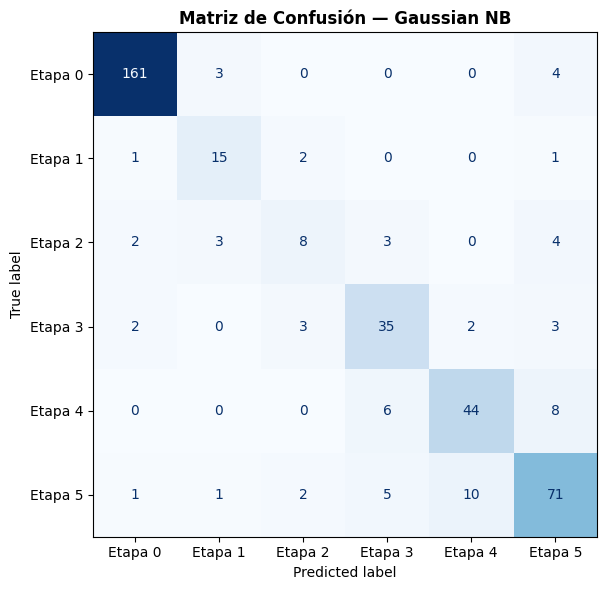


# Decision Tree
              precision    recall  f1-score   support

     Etapa 0       0.96      0.98      0.97       168
     Etapa 1       0.78      0.74      0.76        19
     Etapa 2       0.75      0.75      0.75        20
     Etapa 3       0.87      0.91      0.89        45
     Etapa 4       0.95      0.91      0.93        58
     Etapa 5       0.88      0.86      0.87        90

    accuracy                           0.91       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.91      0.91      0.91       400



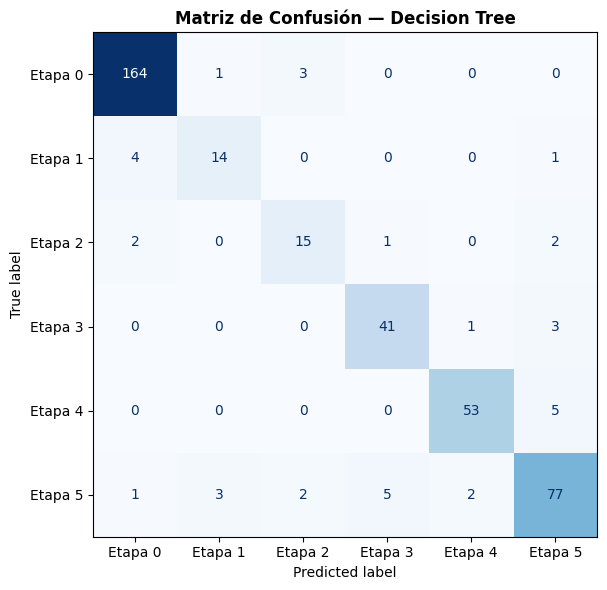


# Random Forest
              precision    recall  f1-score   support

     Etapa 0       0.99      0.99      0.99       168
     Etapa 1       0.83      1.00      0.90        19
     Etapa 2       0.88      0.75      0.81        20
     Etapa 3       0.80      0.96      0.87        45
     Etapa 4       0.93      0.97      0.95        58
     Etapa 5       0.97      0.84      0.90        90

    accuracy                           0.94       400
   macro avg       0.90      0.92      0.90       400
weighted avg       0.94      0.94      0.94       400



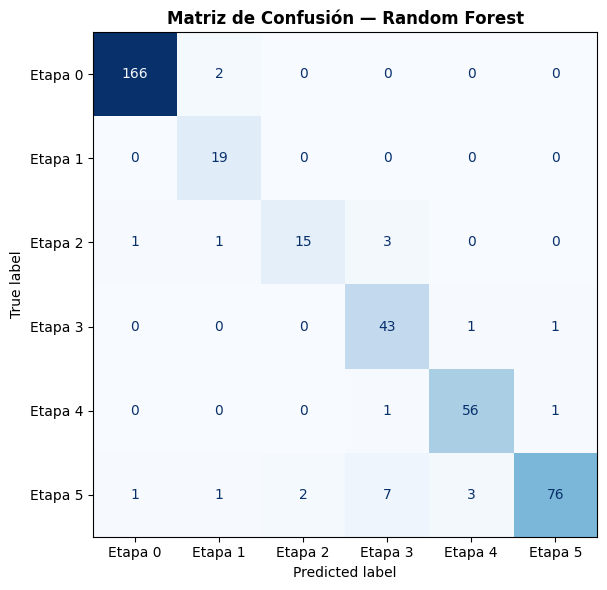


# SVM
              precision    recall  f1-score   support

     Etapa 0       0.50      0.46      0.48       168
     Etapa 1       0.00      0.00      0.00        19
     Etapa 2       0.07      0.45      0.13        20
     Etapa 3       0.03      0.02      0.03        45
     Etapa 4       0.36      0.21      0.26        58
     Etapa 5       0.19      0.07      0.10        90

    accuracy                           0.26       400
   macro avg       0.19      0.20      0.17       400
weighted avg       0.31      0.26      0.27       400



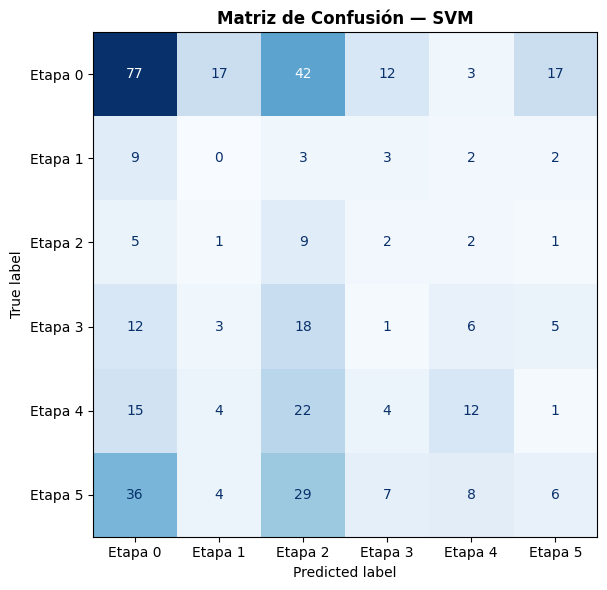

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

smote = SMOTE(random_state=42)

for nombre, modelo in modelos.items():
    print(f"\n{'='*50}")
    print(f"# {nombre}")
    print(f"{'='*50}")

    # Acumular predicciones de todos los folds
    y_real_total = []
    y_pred_total = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

        modelo.fit(X_train_bal, y_train_bal)
        predictions = modelo.predict(X_test)

        y_real_total.extend(y_test)
        y_pred_total.extend(predictions)

    # Classification report
    print(classification_report(y_real_total, y_pred_total,
                                target_names=[f'Etapa {i}' for i in range(6)]))

    # Matriz de confusión
    cm = confusion_matrix(y_real_total, y_pred_total)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=[f'Etapa {i}' for i in range(6)])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión — {nombre}', fontweight='bold')
    plt.tight_layout()
    plt.show()

Selección de métricas:

**Recall (Sensibilidad):** Mide la capacidad del modelo de identificar correctamente a los pacientes que realmente pertenecen a una etapa determinada. Recall bajo implica generación de falsos negativos, esto tiene consecuencias como el no recibimiento del tratamiento adecuado, acelerando el deterioro de la CKD.

**F1-Score Macro:** Promedio armónico entre Precision y Recall, se elige la variante macro ya que está trata a todas las etapas por igual independientemente de cuántos pacientes tenga cada una, fundamental dado el desbalance de clases.

**Accuracy:** Métrica complementaria.

**Conclusión:** Random Forest es el modelo óptimo para el problema, ya que cuenta con un accuracy de 94%, F1 macro de 0.90 y Recall macro de 0.92. Desde la perspectiva clínica, su capacidad de identificar correctamente las etapas intermedias 3 y 4 con Recall de 0.96 y 0.97 respectivamente es especialmente valiosa, ya que son las etapas donde una intervención médica oportuna puede frenar significativamente la progresión hacia la insuficiencia renal terminal.

Gaussian NB — Precision: 0.7432 | Recall: 0.7455 | F1: 0.7419
Decision Tree — Precision: 0.8634 | Recall: 0.8572 | F1: 0.8601
Random Forest — Precision: 0.9001 | Recall: 0.9173 | F1: 0.9044
SVM — Precision: 0.1931 | Recall: 0.2007 | F1: 0.1655

                Precision  Recall  F1 Score
Gaussian NB       0.7432  0.7455    0.7419
Decision Tree     0.8634  0.8572    0.8601
Random Forest     0.9001  0.9173    0.9044
SVM               0.1931  0.2007    0.1655


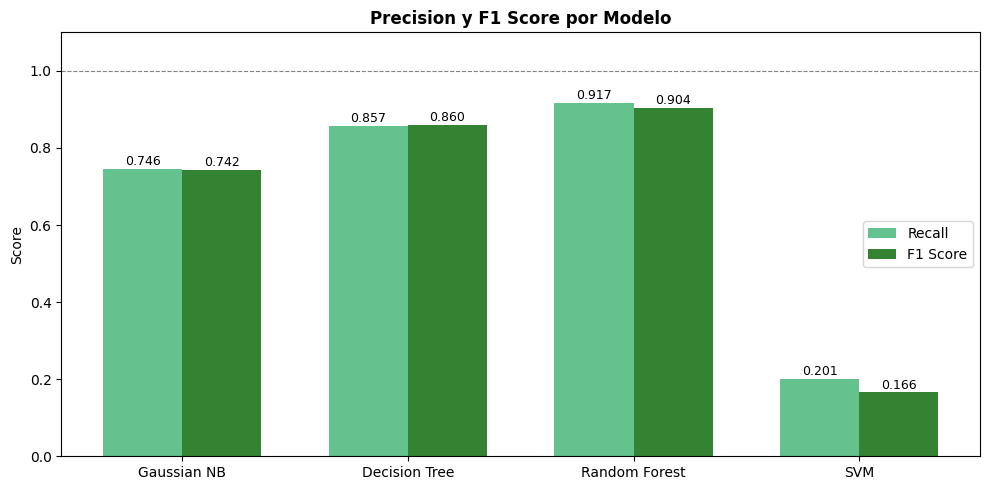

In [ ]:
smote = SMOTE(random_state=42)
resultados_base = {}

for nombre, modelo in modelos.items():
    y_real_total = []
    y_pred_total = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

        modelo.fit(X_train_bal, y_train_bal)
        predictions = modelo.predict(X_test)

        y_real_total.extend(y_test)
        y_pred_total.extend(predictions)

    precision = precision_score(y_real_total, y_pred_total, average='macro')
    recall    = recall_score(y_real_total, y_pred_total, average='macro')
    f1        = f1_score(y_real_total, y_pred_total, average='macro')

    resultados_base[nombre] = {
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4)
    }
    print(f"{nombre} — Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Construir tabla
tabla_base = pd.DataFrame(resultados_base).T
print("\n", tabla_base)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tabla_base))
width = 0.35

ax.bar(x - width/2, tabla_base['Recall'],   width,
       label='Recall',    color='mediumseagreen', alpha=0.8)
ax.bar(x + width/2, tabla_base['F1 Score'], width,
       label='F1 Score',  color='darkgreen', alpha=0.8)

for i, (rec, f1) in enumerate(zip(tabla_base['Recall'], tabla_base['F1 Score'])):
    ax.text(i - width/2, rec + 0.01, f'{rec:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, f1  + 0.01, f'{f1:.3f}',  ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(tabla_base.index)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Precision y F1 Score por Modelo',
             fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
ax.legend()

plt.tight_layout()
plt.show()

# Hiperparámetros

Usamos la estrategia de grid search, esta prueba todas las combinaciones posibles de hiperparámetros que se le definan. El SVM fue descartado de este proceso ya que sus métricas base fueron significativamente inferiores a los demás modelos. También el costo computacional al usar Grid Search con ese modelo era inviable.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Definir grids de hiperparámetros por modelo
param_grids = {
    'Gaussian NB': {
        'modelo': [GaussianNB()],
        'modelo__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'Decision Tree': {
        'modelo': [DecisionTreeClassifier(random_state=42)],
        'modelo__max_depth'        : [3, 5, 10, 15, None],
        'modelo__min_samples_split': [2, 5, 10],
        'modelo__criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'modelo': [RandomForestClassifier(random_state=42)],
        'modelo__n_estimators'     : [50, 100, 200],
        'modelo__max_depth'        : [5, 10, 20, None],
        'modelo__min_samples_split': [2, 5, 10]
    },
    'SVM': {
    'modelo': [SVC(random_state=42)],
    'modelo__C'      : [0.1, 10],
    'modelo__kernel' : ['poly', 'rbf']
    }
}

# Resultados antes y después
resultados_comparacion = {}

for nombre, param_grid in param_grids.items():
    print(f"\n{'='*50}")
    print(f"# {nombre}")
    print(f"{'='*50}")

    # Pipeline con SMOTE
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('modelo', list(param_grid.values())[0][0])
    ])

    # GridSearchCV con StratifiedKFold
    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid,
        cv         = skf,
        scoring    = 'f1_macro',  # F1 macro por desbalance de clases
        n_jobs     = -1,          # Usar todos los núcleos disponibles
        verbose    = 1
    )

    grid_search.fit(X, y)

    # Mejores hiperparámetros encontrados
    print(f"\nMejores hiperparámetros:")
    for param, valor in grid_search.best_params_.items():
        if param != 'modelo':
            print(f"  {param.replace('modelo__', '')}: {valor}")

    print(f"\nMejor F1 macro (con tuning) : {grid_search.best_score_:.4f}")

    resultados_comparacion[nombre] = {
        'mejor_score': grid_search.best_score_,
        'mejor_modelo': grid_search.best_estimator_
    }


# Gaussian NB
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Mejores hiperparámetros:
  var_smoothing: 1e-07

Mejor F1 macro (con tuning) : 0.7955

# Decision Tree
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros:
  criterion: gini
  max_depth: 10
  min_samples_split: 10

Mejor F1 macro (con tuning) : 0.8566

# Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejores hiperparámetros:
  max_depth: 20
  min_samples_split: 2
  n_estimators: 200

Mejor F1 macro (con tuning) : 0.9169

# SVM
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Mejores hiperparámetros:
  C: 10
  kernel: poly

Mejor F1 macro (con tuning) : 0.2213


Gaussian NB — F1 macro antes del tuning: 0.7419
Decision Tree — F1 macro antes del tuning: 0.8601
Random Forest — F1 macro antes del tuning: 0.9044
SVM — F1 macro antes del tuning: 0.1655
       Modelo  Antes (F1)  Después (F1)  Mejora
  Gaussian NB      0.7419      0.795535  0.0536
Decision Tree      0.8601      0.856625 -0.0035
Random Forest      0.9044      0.916874  0.0125
          SVM      0.1655      0.221329  0.0558


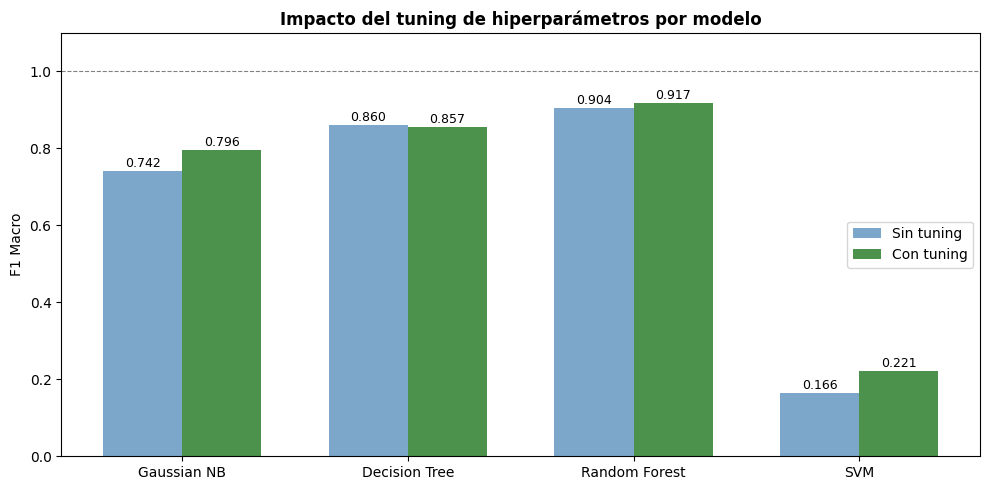

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score

scores_antes = {}

smote = SMOTE(random_state=42)

modelos = {
    'Gaussian NB':GaussianNB(),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

for nombre, modelo in modelos.items():
    y_real_total = []
    y_pred_total = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

        modelo.fit(X_train_bal, y_train_bal)
        predictions = modelo.predict(X_test)

        y_real_total.extend(y_test)
        y_pred_total.extend(predictions)

    f1 = f1_score(y_real_total, y_pred_total, average='macro')
    scores_antes[nombre] = round(f1, 4)
    print(f"{nombre} — F1 macro antes del tuning: {f1:.4f}")

# Construir tabla comparativa
tabla = pd.DataFrame({
    'Modelo'        : list(scores_antes.keys()),
    'Antes (F1)'    : list(scores_antes.values()),
    'Después (F1)'  : [resultados_comparacion[m]['mejor_score']
                       for m in scores_antes.keys()],
})

tabla['Mejora'] = (tabla['Después (F1)'] - tabla['Antes (F1)']).round(4)
print(tabla.to_string(index=False))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tabla['Modelo']))
width = 0.35

ax.bar(x - width/2, tabla['Antes (F1)'],  width, label='Sin tuning',  color='steelblue', alpha=0.7)
ax.bar(x + width/2, tabla['Después (F1)'], width, label='Con tuning', color='darkgreen', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(tabla['Modelo'])
ax.set_ylabel('F1 Macro')
ax.set_title('Impacto del tuning de hiperparámetros por modelo', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for i, (antes, despues) in enumerate(zip(tabla['Antes (F1)'], tabla['Después (F1)'])):
    ax.text(i - width/2, antes + 0.01, f'{antes:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, despues + 0.01, f'{despues:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

El tunning de hiperparámetros para Decision Tree no presenta una mejora, más bien tiene una diferencia de 0.003, esto puede ser debido a que los parámetros definidos no incluía los óptimos reales, es decir, los parámetros por defecto de sklearn funcionan mejor que las combinaciones probadas.

# Análisis profundo

In [ ]:
# Definir modelo con hiperparámetros optimizados
rf_optimizado = RandomForestClassifier(
    max_depth=20,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)

# Acumular predicciones con StratifiedKFold + SMOTE
smote = SMOTE(random_state=42)
y_real_total = []
y_pred_total = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    rf_optimizado.fit(X_train_bal, y_train_bal)
    predictions = rf_optimizado.predict(X_test)

    y_real_total.extend(y_test)
    y_pred_total.extend(predictions)

print(classification_report(y_real_total, y_pred_total,
                            target_names=[f'Etapa {i}' for i in range(6)]))

              precision    recall  f1-score   support

     Etapa 0       0.99      0.99      0.99       168
     Etapa 1       0.86      1.00      0.93        19
     Etapa 2       0.94      0.80      0.86        20
     Etapa 3       0.80      0.98      0.88        45
     Etapa 4       0.93      0.97      0.95        58
     Etapa 5       0.99      0.86      0.92        90

    accuracy                           0.94       400
   macro avg       0.92      0.93      0.92       400
weighted avg       0.95      0.94      0.95       400



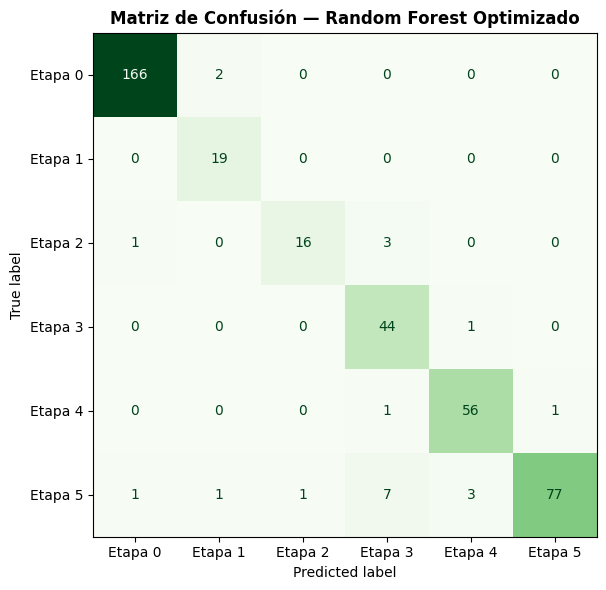

In [ ]:
cm = confusion_matrix(y_real_total, y_pred_total)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[f'Etapa {i}' for i in range(6)])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de Confusión — Random Forest Optimizado', fontweight='bold')
plt.tight_layout()
plt.show()

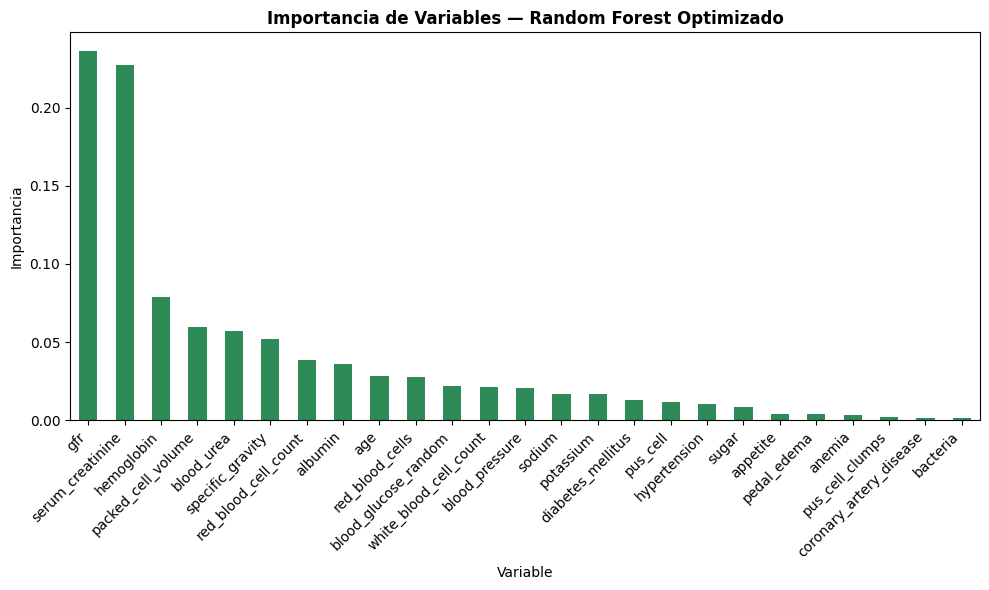


Top 5 variables más importantes:
gfr                   0.236522
serum_creatinine      0.227695
hemoglobin            0.078909
packed_cell_volume    0.059932
blood_urea            0.057404
dtype: float64


In [ ]:
# Entrenar una vez sobre todo el dataset para obtener feature importances
rf_optimizado.fit(X, y)

importancias = pd.Series(rf_optimizado.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.plot(kind='bar', color='seagreen', ax=ax)
ax.set_title('Importancia de Variables — Random Forest Optimizado', fontweight='bold')
ax.set_ylabel('Importancia')
ax.set_xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 variables más importantes:")
print(importancias.head(5))

In [ ]:
y_real_arr = np.array(y_real_total)
y_pred_arr = np.array(y_pred_total)

print("Análisis de errores por etapa:")
print(f"{'Etapa':<10} {'Total':<10} {'Correctos':<12} {'Errores':<10} {'% Error':<10}")
print("-" * 55)

for etapa in range(6):
    mask = y_real_arr == etapa
    total = mask.sum()
    correctos = (y_pred_arr[mask] == etapa).sum()
    errores = total - correctos
    pct_error = (errores / total * 100) if total > 0 else 0
    print(f"Etapa {etapa:<5} {total:<10} {correctos:<12} {errores:<10} {pct_error:.1f}%")

# Analizar hacia donde se van los errores
print("\nPatrones de confusión más frecuentes:")
errores_idx = y_real_arr != y_pred_arr
y_real_err = y_real_arr[errores_idx]
y_pred_err = y_pred_arr[errores_idx]

from collections import Counter
patrones = Counter(zip(y_real_err, y_pred_err))
for (real, pred), conteo in patrones.most_common(10):
    print(f"  Etapa {real} clasificada como Etapa {pred}: {conteo} casos")

Análisis de errores por etapa:
Etapa      Total      Correctos    Errores    % Error   
-------------------------------------------------------
Etapa 0     168        166          2          1.2%
Etapa 1     19         19           0          0.0%
Etapa 2     20         16           4          20.0%
Etapa 3     45         44           1          2.2%
Etapa 4     58         56           2          3.4%
Etapa 5     90         77           13         14.4%

Patrones de confusión más frecuentes:
  Etapa 5.0 clasificada como Etapa 3.0: 7 casos
  Etapa 2.0 clasificada como Etapa 3.0: 3 casos
  Etapa 5.0 clasificada como Etapa 4.0: 3 casos
  Etapa 0.0 clasificada como Etapa 1.0: 2 casos
  Etapa 4.0 clasificada como Etapa 5.0: 1 casos
  Etapa 3.0 clasificada como Etapa 4.0: 1 casos
  Etapa 4.0 clasificada como Etapa 3.0: 1 casos
  Etapa 5.0 clasificada como Etapa 1.0: 1 casos
  Etapa 2.0 clasificada como Etapa 0.0: 1 casos
  Etapa 5.0 clasificada como Etapa 0.0: 1 casos
